In [8]:
library(readxl)
library(writexl)
library(ggplot2)
library(dplyr)

In [9]:
female_data <- read_excel("raw_data/female_data.xlsx")
head(female_data)

# A tibble: 6 × 8
  ks    tl                   umur sex      tb    bb    bf   bmi
  <chr> <dttm>              <dbl> <chr> <dbl> <dbl> <dbl> <dbl>
1 SM715 2012-10-16 00:00:00  12.9 F      141   36.2  11.4  18.2
2 SM716 2012-06-29 00:00:00  13.3 F      158.  45.1  13.3  18  
3 SM717 2013-03-19 00:00:00  12.5 F      142.  43.7  26.2  21.8
4 SM718 2012-12-14 00:00:00  12.8 F      148   55.4  71.1  25.3
5 SM719 2013-02-20 00:00:00  12.6 F      128   38.5  24.2  23.5
6 SM720 2012-12-16 00:00:00  12.8 F      146   43.6  23    20.5

In [10]:
female_data <- as.data.frame(female_data)
female_data$bmi_zscore <- scale(female_data$bmi)
female_data <- female_data %>% 
  mutate(bmi_category = case_when(
    bmi_zscore < -3       ~ "Gizi Buruk",
    bmi_zscore >= -3 & bmi_zscore < -2 ~ "Gizi Kurang",
    bmi_zscore >= -2 & bmi_zscore <= 1 ~ "Gizi Normal",
    bmi_zscore > 1   & bmi_zscore <= 2 ~ "Gizi Lebih",
    bmi_zscore > 2                     ~ "Obesitas",
    is.na(bmi_zscore)                  ~ NA_character_
  )) 

In [11]:
female_data

        ks         tl umur sex    tb    bb   bf  bmi  bmi_zscore bmi_category
1    SM715 2012-10-16 12.9   F 141.0 36.20 11.4 18.2 -0.53907870  Gizi Normal
2    SM716 2012-06-29 13.3   F 158.5 45.10 13.3 18.0 -0.58692312  Gizi Normal
3    SM717 2013-03-19 12.5   F 141.5 43.70 26.2 21.8  0.32212084  Gizi Normal
4    SM718 2012-12-14 12.8   F 148.0 55.40 71.1 25.3  1.15939817   Gizi Lebih
5    SM719 2013-02-20 12.6   F 128.0 38.50 24.2 23.5  0.72879840  Gizi Normal
6    SM720 2012-12-16 12.8   F 146.0 43.60 23.0 20.5  0.01113212  Gizi Normal
7    SM721 2013-01-22 12.7   F 155.0 38.80 15.0 16.0 -1.06536730  Gizi Normal
8    SM722 2010-09-12 15.0   F 162.0 47.00 21.4 17.9 -0.61084533  Gizi Normal
9    SM723 2012-11-10 12.8   F 150.0 35.50  7.1 15.8 -1.11321172  Gizi Normal
10   SM724 2012-12-19 12.8   F 135.0 32.00 13.5 17.5 -0.70653416  Gizi Normal
11   SM725 2013-04-25 12.4   F 140.0 43.40 25.8 22.1  0.39388747  Gizi Normal
12   SM726 2013-01-30 12.7   F 146.5 41.40 21.8 19.3 -0.27593439

In [12]:
write_xlsx(female_data, "clean_data/female_nutritional_status.xlsx")

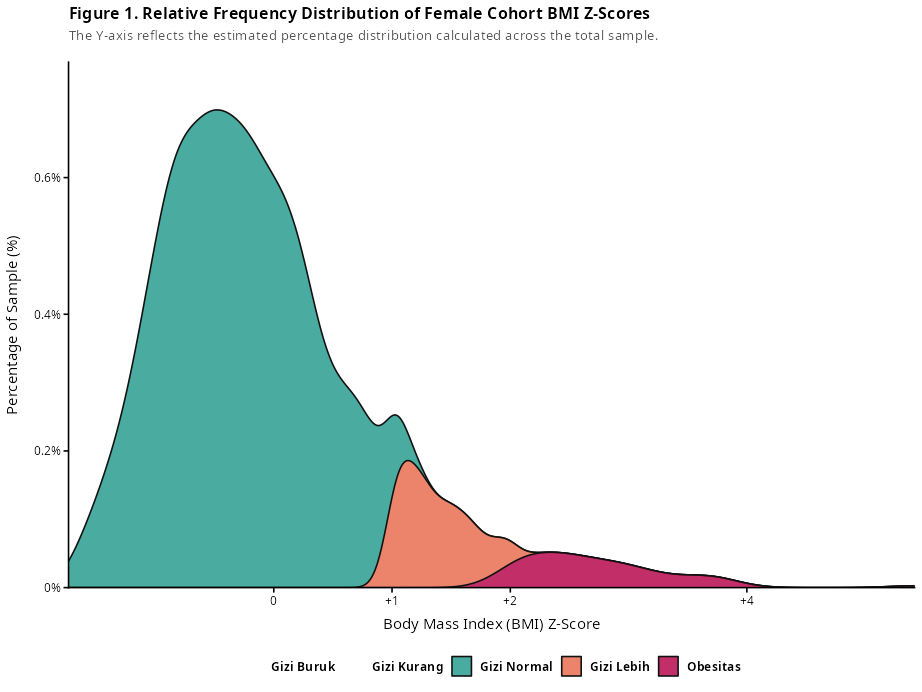

In [19]:
library(ggplot2)
library(dplyr)

# 1. Clean data and ensure strict factor ordering
plot_df <- female_data %>% 
  filter(!is.na(bmi_zscore)) %>%
  mutate(bmi_category = factor(bmi_category, levels = c(
    "Gizi Buruk", "Gizi Kurang", "Gizi Normal", "Gizi Lebih", "Obesitas"
  )))

# 2. Plot with True Percentage on the Y-Axis
ggplot(plot_df, aes(x = bmi_zscore)) +
  # Draw the smooth area curve scaled to percentage
  geom_area(
    aes(y = after_stat(count) / sum(after_stat(count)) * 100, fill = bmi_category),
    stat = "density",
    alpha = 0.85,
    color = "#111111", # Crisp black bounding line
    linewidth = 0.6
  ) +
  
  # Standard academic publication palette
  scale_fill_manual(
    values = c(
      "Gizi Buruk"  = "#4a6fa5", 
      "Gizi Kurang" = "#8ab17d", 
      "Gizi Normal" = "#2a9d8f", 
      "Gizi Lebih"  = "#e76f51", 
      "Obesitas"    = "#b7094c"
    ),
    drop = FALSE
  ) +
  
  # Structural X-axis breaks matching your clinical thresholds
  scale_x_continuous(
    breaks = c(-4, -3, -2, 0, 1, 2, 4), 
    labels = c("-4", "-3", "-2", "0", "+1", "+2", "+4"),
    expand = c(0, 0)
  ) +
  
  # True Percentage Y-axis scaling
  scale_y_continuous(
    labels = function(x) paste0(x, "%"),
    expand = expansion(mult = c(0, 0.1))
  ) +
  
  # Rigid Q1 Journal Theme Specifications
  theme_classic(base_size = 12, base_family = "sans") + 
  theme(
    axis.line = element_line(color = "black", linewidth = 0.6),
    axis.ticks = element_line(color = "black", linewidth = 0.6),
    axis.ticks.length = unit(4, "pt"),
    panel.grid = element_blank(),
    
    plot.title = element_text(face = "bold", size = 13, hjust = 0),
    plot.subtitle = element_text(size = 11, color = "grey30", hjust = 0, margin = margin(b = 15)),
    
    legend.position = "bottom",
    legend.title = element_blank(),
    legend.text = element_text(size = 10, face = "bold"),
    
    axis.title.x = element_text(face = "plain", margin = margin(t = 10)),
    axis.title.y = element_text(face = "plain", margin = margin(r = 10))
  ) +
  labs(
    title = "Figure 1. Relative Frequency Distribution of Female Cohort BMI Z-Scores",
    subtitle = "The Y-axis reflects the estimated percentage distribution calculated across the total sample.",
    x = "Body Mass Index (BMI) Z-Score",
    y = "Percentage of Sample (%)"
  )

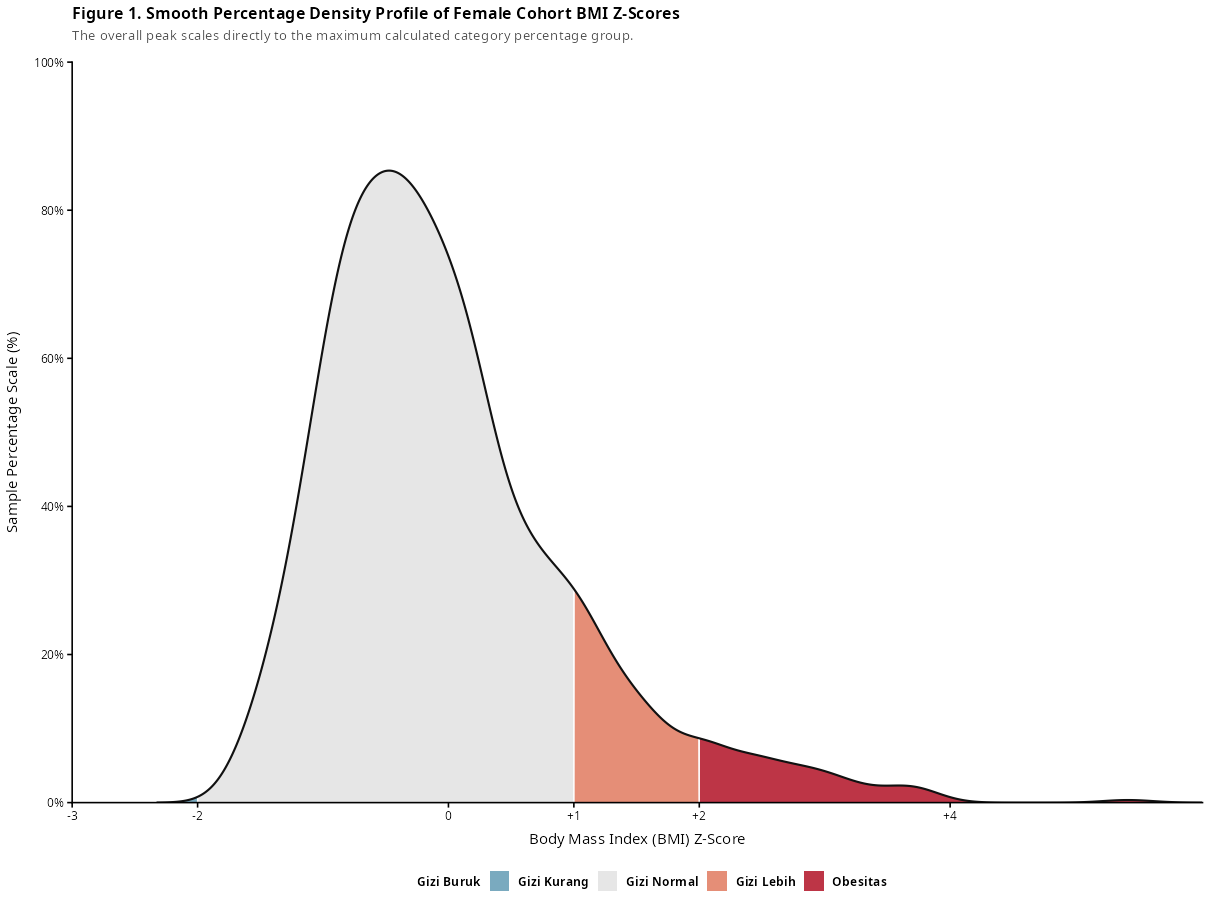

In [31]:
library(ggplot2)
library(dplyr)

# 1. Clean data and compute the precise category percentages
counts_df <- female_data %>%
  filter(!is.na(bmi_zscore)) %>%
  count(bmi_category) %>%
  mutate(pct = (n / sum(n)) * 100)

# Identify the macro percentage of your largest category (e.g., Gizi Normal might be 65%)
max_category_pct <- max(counts_df$pct)

# 2. Extract the base continuous density curve
dens <- density(female_data$bmi_zscore, n = 1024, na.rm = TRUE)

# Build a continuous dataframe and calculate a smooth multiplier 
# so the highest peak perfectly matches your highest category percentage
df_smooth <- data.frame(x = dens$x, y = dens$y) %>%
  mutate(
    # This keeps the curve perfectly fluid while scaling the peak to your true %
    y_scaled = (y / max(y)) * max_category_pct,
    
    # Map coordinates to categories for the color fills
    bmi_category = case_when(
      x < -3           ~ "Gizi Buruk",
      x >= -3 & x < -2 ~ "Gizi Kurang",
      x >= -2 & x <= 1 ~ "Gizi Normal",
      x > 1   & x <= 2 ~ "Gizi Lebih",
      x > 2            ~ "Obesitas"
    ),
    bmi_category = factor(bmi_category, levels = c(
      "Gizi Buruk", "Gizi Kurang", "Gizi Normal", "Gizi Lebih", "Obesitas"
    ))
  )

# 3. Plot the Fluid Percentage Density Curve
ggplot(df_smooth, aes(x = x, y = y_scaled)) +
  # Continuous area fill without broken internal drop-offs
  geom_area(aes(fill = bmi_category), alpha = 0.85, color = NA) +
  
  # Thin vertical white lines exactly at clinical cutoffs to show transitions clearly
  geom_vline(xintercept = c(-3, -2, 1, 2), color = "white", linewidth = 0.5) +
  
  # A single smooth, continuous outline over the top of the entire distribution
  geom_line(color = "#111111", linewidth = 0.8) + 
  
  # Premium Journal color palette
  scale_fill_manual(
    values = c(
    "Gizi Buruk"  = "#31688e",  # Muted Slate Blue (Severe deficit)
    "Gizi Kurang" = "#639bb4",  # Soft Steel Blue (Moderate deficit)
    "Gizi Normal" = "#e2e2e2",  # Neutral Light Gray (The baseline/normal anchor)
    "Gizi Lebih"  = "#e07a5f",  # Muted Terracotta (Moderate excess)
    "Obesitas"    = "#b11226"   # Deep Crimson (Severe excess)
    ),
    drop = FALSE
  ) +

  
  # X-axis structured strictly around WHO clinical markers
  scale_x_continuous(
    breaks = c(-4, -3, -2, 0, 1, 2, 4), 
    labels = c("-4", "-3", "-2", "0", "+1", "+2", "+4"),
    expand = c(0, 0)
  ) +
  
  # Rigid Y-axis limits scaling beautifully from 0 to 100%
  scale_y_continuous(
    limits = c(0, 100),
    breaks = seq(0, 100, by = 20),
    labels = function(x) paste0(x, "%"),
    expand = c(0, 0)
  ) +
  
  # Strict Q1 Journal Layout Template
  theme_classic(base_size = 12, base_family = "sans") + 
  theme(
    axis.line = element_line(color = "black", linewidth = 0.6),
    axis.ticks = element_line(color = "black", linewidth = 0.6),
    axis.ticks.length = unit(4, "pt"),
    panel.grid = element_blank(),
    
    plot.title = element_text(face = "bold", size = 13, hjust = 0),
    plot.subtitle = element_text(size = 11, color = "grey30", hjust = 0, margin = margin(b = 15)),
    
    legend.position = "bottom",
    legend.title = element_blank(),
    legend.text = element_text(size = 10, face = "bold"),
    
    axis.title.x = element_text(face = "plain", margin = margin(t = 10)),
    axis.title.y = element_text(face = "plain", margin = margin(r = 10))
  ) +
  labs(
    title = "Figure 1. Smooth Percentage Density Profile of Female Cohort BMI Z-Scores",
    subtitle = "The overall peak scales directly to the maximum calculated category percentage group.",
    x = "Body Mass Index (BMI) Z-Score",
    y = "Sample Percentage Scale (%)"
  )